In [1]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def load_scores(file_path):
    steps = []
    scores = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            steps.append(data['step'])
            scores.append(data['episode/score'])
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def plot_agent_scores(jsonl_paths, labels=None, window_size=50):
    from matplotlib.ticker import FuncFormatter
    color_list = ['tab:green', 'tab:pink', 'tab:grey', 'tab:blue']
    plt.figure(figsize=(4, 3))

    for i, path in enumerate(jsonl_paths):
        steps, scores = load_scores(path)

        # Sort by steps in case data is unordered
        sorted_indices = np.argsort(steps)
        steps, scores = steps[sorted_indices], scores[sorted_indices]

        # Apply smoothing
        smoothed_scores = smooth(scores, window_size)
        smoothed_steps = smooth(steps, window_size)

        # Compute std for shading
        #std = np.std(scores)
        std=0

        label = labels[i] if labels else f"Agent {i+1}"
        smoothed_steps = smoothed_steps/1e6
        plt.plot(smoothed_steps, smoothed_scores, label=label, c=color_list[i], linewidth=5)
        #plt.fill_between(smoothed_steps, smoothed_scores - std, smoothed_scores + std, alpha=0.2)

    plt.xlabel("Steps")
    #plt.ylabel("Score")
    plt.xticks([5, 10], ['5M', '10M'])  # Show only 5M and 10M
    plt.legend()
    plt.grid(True)
    plt.xlim(0,10)
    plt.tight_layout()
    plt.show()


In [2]:
plt.rcParams.update({'font.size': 16})

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator
from matplotlib.ticker import MaxNLocator

from matplotlib.ticker import FuncFormatter

def load_scores(file_path):
    steps, scores = [], []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'step' in data and 'episode/score' in data:
                        steps.append(data['step'])
                        scores.append(data['episode/score'])
                except json.JSONDecodeError as e:
                    print(f"[Warning] JSON decode error in {file_path}: {e}")
    except Exception as e:
        print(f"[Warning] Failed to open {file_path}: {e}")
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def find_jsonl_files_recursively(folder_path):
    jsonl_files = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file == 'scores.jsonl':
                jsonl_files.append(os.path.join(root, file))
    return jsonl_files

def aggregate_runs_in_folder(folder_path, window_size=50, use_ste=True):
    run_files = find_jsonl_files_recursively(folder_path)
    all_runs = []

    for path in run_files:
        steps, scores = load_scores(path)
        if len(steps) == 0 or len(scores) == 0:
            print(f"[Info] Skipping empty or bad file: {path}")
            continue

        sorted_indices = np.argsort(steps)
        steps, scores = steps[sorted_indices], scores[sorted_indices]
        all_runs.append((steps, scores))

    if len(all_runs) == 0:
        raise ValueError(f"No valid runs found in folder: {folder_path}")

    # Determine shared interpolation range
    min_end = min([steps[-1] for steps, _ in all_runs])
    max_start = max([steps[0] for steps, _ in all_runs])
    if min_end <= max_start:
        raise ValueError(f"Insufficient overlapping range in folder: {folder_path}")

    common_steps = np.linspace(max_start, min_end, 500)

    interpolated_scores = []
    for steps, scores in all_runs:
        interp_scores = np.interp(common_steps, steps, scores)
        interpolated_scores.append(interp_scores)

    interpolated_scores = np.array(interpolated_scores)
    mean_scores = np.mean(interpolated_scores, axis=0)
    error = (np.std(interpolated_scores, axis=0) / np.sqrt(len(interpolated_scores))) if use_ste else np.std(interpolated_scores, axis=0)

    # Smooth
    smoothed_mean = smooth(mean_scores, window_size)
    smoothed_error = smooth(error, window_size)
    smoothed_steps = smooth(common_steps, window_size)

    return smoothed_steps, smoothed_mean, smoothed_error

def plot_agent_folders(folder_paths, labels=None, window_size=50, use_ste=True, color_list=['tab:green', 'tab:pink', 'tab:grey', 'tab:blue', 'tab:orange', 'tab:red']):

    plt.figure(figsize=(4, 3))

    for i, folder in enumerate(folder_paths):
        try:
            steps, mean_scores, error = aggregate_runs_in_folder(folder, window_size, use_ste)
        except ValueError as e:
            print(f"[Error] Skipping folder due to issue: {e}")
            continue

        label = labels[i] if labels else f"Agent {i+1}"
        color = color_list[i % len(color_list)]
        steps = steps / 1e6
        plt.plot(steps, mean_scores, label=label, c=color, linewidth=5)
        plt.fill_between(steps, mean_scores - error, mean_scores + error, color=color, alpha=0.3)

    # Format x-axis ticks like "0", "5M", "10M"
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}M' if x != 0 else '0'))

    plt.xticks([5, 10], ['5M', '10M'])  # Show only 5M and 10M
    
    #ax = plt.gca()
    #ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None, integer=True))
    
    plt.xlabel("Steps")
    #plt.ylabel("Score")
    #plt.legend()
    #plt.legend(bbox_to_anchor=(0.5, -0.5))
    
    
    legend_y = -0.3 if len(folder_paths) <= 2 else -0.5
    #plt.legend(bbox_to_anchor=(0.5, legend_y), loc='upper center')

    plt.xlim(0, 10)
    plt.grid(True)
    #plt.tight_layout()
    #plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.tight_layout()

    plt.show()


[Error] Skipping folder due to issue: No valid runs found in folder: logdir/dmc_cheetah_run/Viper/
[Error] Skipping folder due to issue: No valid runs found in folder: logdir/dmc_cheetah_run/XViper/
[Error] Skipping folder due to issue: No valid runs found in folder: logdir/dmc_cheetah_run/4/


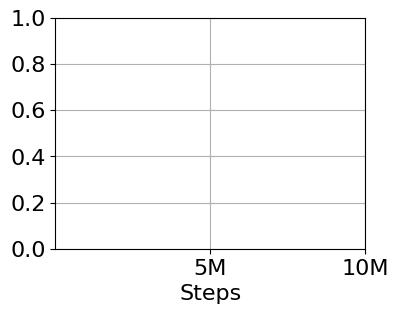

In [4]:
folders = ['logdir/dmc_cheetah_run/Viper/', 'logdir/dmc_cheetah_run/XViper/', 'logdir/dmc_cheetah_run/4/']
labels = ['VIPER', 'XVIPER', 'Orcale']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

In [4]:
plt.rcParams.update({'font.size': 16})

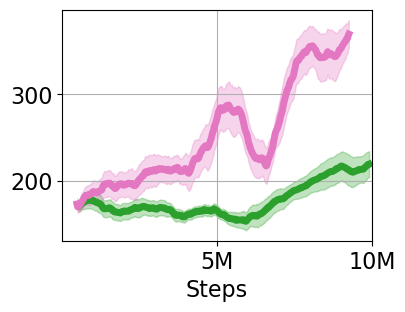

In [7]:
folders = ['logdir/dmc_cartpole_balance/Viper/', 'logdir/dmc_cartpole_balance/XViper/']
labels = ['VIPER', 'XVIPER', 'Orcale']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

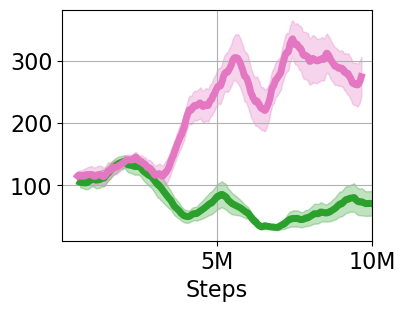

In [8]:
folders = ['logdir/dmc_cartpole_swingup/Viper/', 'logdir/dmc_cartpole_swingup/XViper/']
labels = ['VIPER', 'XVIPER', 'Orcale']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

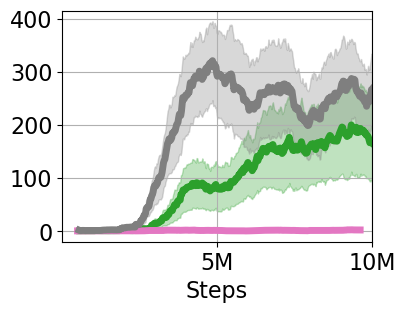

In [9]:
folders = ['logdir/dmc_pointmass_easy/Viper/', 'logdir/dmc_pointmass_easy/XViper/', 'logdir/dmc_pointmass_easy/XViper_separateOT_expert_data_best_ot/']
labels = ['VIPER', 'XVIPER', 'XVIER-E/R']
plot_agent_folders(folders, labels, window_size=50, use_ste=True)

### XIPER with different OT (FID) and training data

In [4]:
from matplotlib.colors import to_rgb

In [5]:
def adjust_shade(rgb, factor):
    return tuple(min(1, c * factor) for c in rgb)

In [6]:
base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 0.6), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.2)]

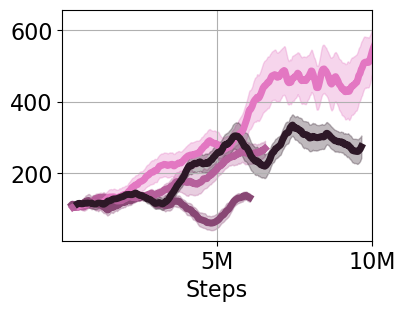

In [17]:
folders = ['logdir/dmc_cartpole_swingup/XViper_separateOT_expert_data/', 'logdir/dmc_cartpole_swingup/XViper_separateOT_expert_data_2999ot/', 'logdir/dmc_cartpole_swingup/XViper_separateOT_expert_data_best_ot/', 'logdir/dmc_cartpole_swingup/XViper/']
labels = ['XIPER-E/R-FID69', 'XIPER-E/R-FID44', 'XIPER-E/R-FID36', 'XIPER-R']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

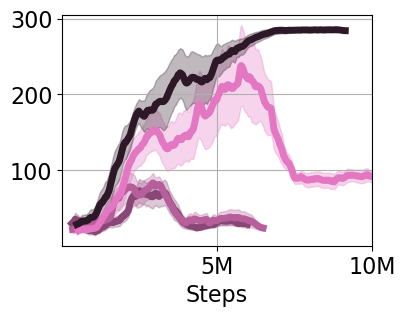

In [18]:
folders = ['logdir/dmc_cheetah_run/XViper_separateOT_expert_data/', 'logdir/dmc_cheetah_run/XViper_separateOT_expert_data_2999ot/', 'logdir/dmc_cheetah_run/XViper_separateOT_expert_data_best_ot/', 'logdir/dmc_cheetah_run/XViper/']
labels = ['XIPER-E/R-FID23', 'XIPER-E/R-FID20', 'XIPER-E/R-FID18', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 0.6), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

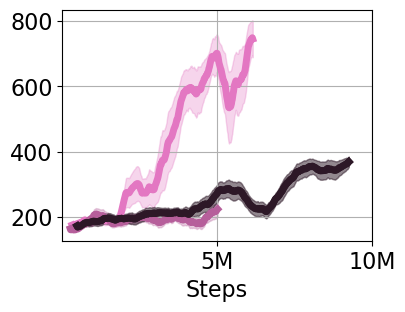

In [21]:
folders = ['logdir/dmc_cartpole_balance/XViper_separateOT_expert_data/', 'logdir/dmc_cartpole_balance/XViper_separateOT_expert_data_2999ot/', 'logdir/dmc_cartpole_balance/XViper/', 'logdir/dmc_cartpole_balance/XViper/']
labels = ['XIPER-E/R-FID47', 'XIPER-E/R-FID64', 'XIPER-R', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

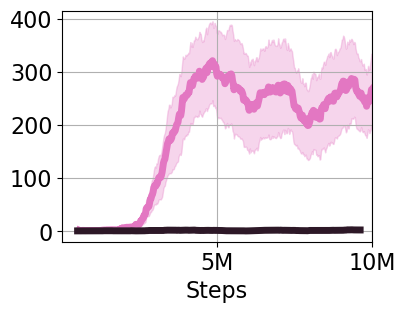

In [22]:
folders = ['logdir/dmc_pointmass_easy/XViper_separateOT_expert_data_best_ot/', 'logdir/dmc_pointmass_easy/XViper/']
labels = ['XIPER-E/R-FID18', 'XIPER-R']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

### with OT_R

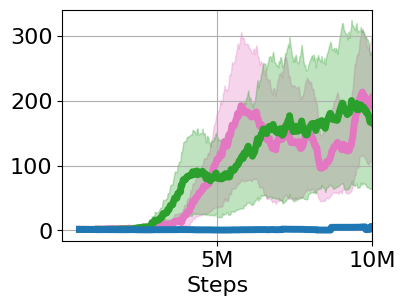

In [4]:
folders = ['logdir/DMC_results_xiper_viper/dmc_pointmass_easy/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_pointmass_easy/Viper/', 'logdir/dmc_pointmass_easy/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

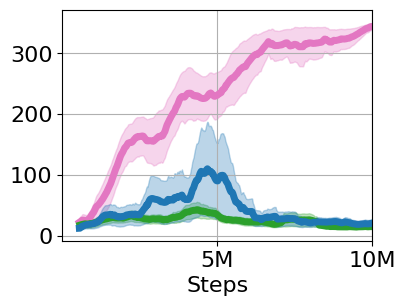

In [36]:
folders = ['logdir/DMC_results_xiper_viper/dmc_cheetah_run/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_cheetah_run/Viper/', 'logdir/dmc_cheetah_run/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

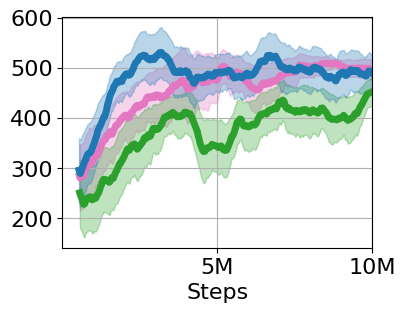

In [54]:
folders = ['logdir/DMC_results_xiper_viper/dmc_quadruped_walk/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_quadruped_walk/Viper_3_seeds/', 'logdir/dmc_quadruped_walk/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL', 'SXIPER', 'SVIPER']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

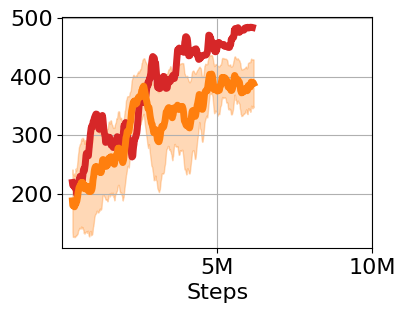

In [52]:
folders = ['./logdir/dmc_quadruped_walk/Xiper_stronger_RM/', './logdir/dmc_quadruped_walk/Viper_stronger_RM/']
labels = ['SXIPER', 'SVIPER']

color_list = ['tab:red', 'tab:orange', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

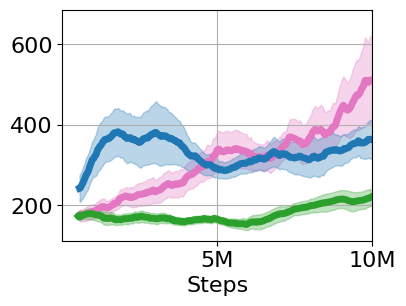

In [56]:
folders = ['logdir/DMC_results_xiper_viper/dmc_cartpole_balance/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_cartpole_balance/Viper/', 'logdir/dmc_cartpole_balance/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL', 'SXIPER', 'SVIPER']

color_list = ['tab:pink', 'tab:green', 'tab:blue', 'tab:red', 'tab:orange']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

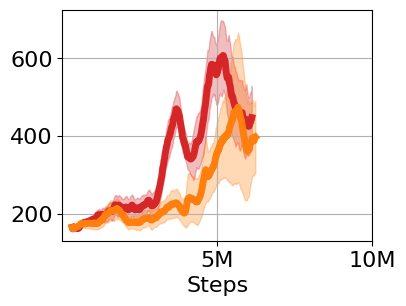

In [51]:
folders = ['./logdir/dmc_cartpole_balance/Xiper_stronger_RM/', './logdir/dmc_cartpole_balance/Viper_stronger_RM/']
labels = ['SXIPER', 'SVIPER']

color_list = ['tab:red', 'tab:orange', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

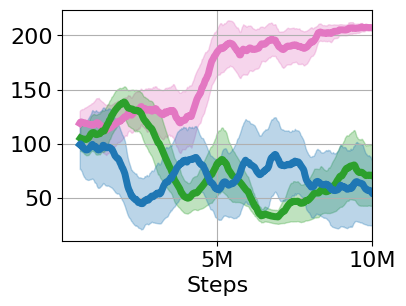

In [40]:
folders = ['logdir/DMC_results_xiper_viper/dmc_cartpole_swingup/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_cartpole_swingup/Viper/', 'logdir/dmc_cartpole_swingup/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

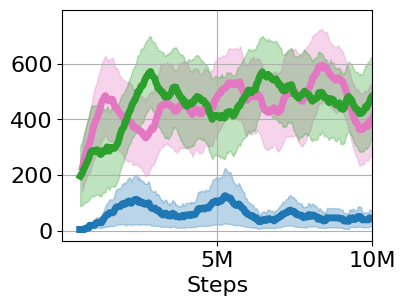

In [20]:
folders = ['logdir/DMC_results_xiper_viper/dmc_pendulum_swingup/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_pendulum_swingup/Viper_3_seeds/', 'logdir/dmc_pendulum_swingup/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

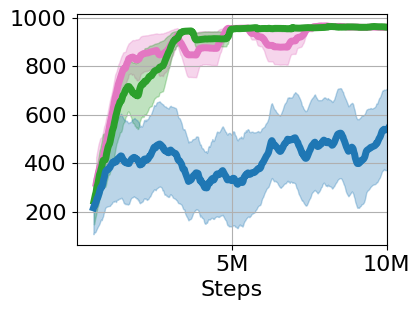

In [21]:
folders = ['logdir/DMC_results_xiper_viper/dmc_cup_catch/Xiper_ot_R/', 'logdir/DMC_results_xiper_viper/dmc_cup_catch/Viper_3_seeds/', 'logdir/dmc_cup_catch/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

### Atari

In [5]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Atari Normalization Scores ----------
ATARI_NORMALIZATION_SCORES = {
    'pong': {'random': -20.7, 'human': 15.0},
    'kangaroo': {'random': 52.0, 'human': 3035.0},
    'boxing': {'random': 0.1, 'human': 12.1}
}

# ---------- Load and Smooth ----------
def load_scores(file_path):
    steps, scores = [], []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'step' in data and 'episode/score' in data:
                        steps.append(data['step'])
                        scores.append(data['episode/score'])
                except json.JSONDecodeError as e:
                    print(f"[Warning] JSON decode error in {file_path}: {e}")
    except Exception as e:
        print(f"[Warning] Failed to open {file_path}: {e}")
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def find_jsonl_files_recursively(folder_path):
    jsonl_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file == 'scores.jsonl':
                jsonl_files.append(os.path.join(root, file))
    return jsonl_files

# ---------- Normalize Atari Scores ----------
def normalize_atari_scores(game_name, scores):
    game_name = game_name.lower()
    if game_name not in ATARI_NORMALIZATION_SCORES:
        raise ValueError(f"No normalization scores for game: {game_name}")
    rand = ATARI_NORMALIZATION_SCORES[game_name]['random']
    human = ATARI_NORMALIZATION_SCORES[game_name]['human']
    denom = human - rand
    if denom == 0:
        raise ValueError(f"Invalid normalization range for {game_name}")
    return 100 * (scores - rand) / denom

# ---------- Main Aggregation ----------
def aggregate_runs_in_folder(folder_path, window_size=50, use_ste=True, human_normalize=False):
    run_files = find_jsonl_files_recursively(folder_path)
    all_runs = []

    for path in run_files:
        steps, scores = load_scores(path)
        if len(steps) == 0 or len(scores) == 0:
            print(f"[Info] Skipping empty or bad file: {path}")
            continue

        sorted_indices = np.argsort(steps)
        steps, scores = steps[sorted_indices], scores[sorted_indices]
        all_runs.append((steps, scores))

    if len(all_runs) == 0:
        raise ValueError(f"No valid runs found in folder: {folder_path}")

    # ---------- Game name extraction ----------
    game_folder = os.path.basename(os.path.dirname(os.path.dirname(folder_path)))
    if 'atari_' in game_folder:
        game_name = game_folder.replace('atari_', '').lower()
    else:
        game_name = game_folder.lower()

    # Normalize if requested
    if human_normalize:
        try:
            all_runs = [(s, normalize_atari_scores(game_name, y)) for s, y in all_runs]
        except ValueError as e:
            raise ValueError(f"Normalization failed: {e}")

    # Determine shared interpolation range
    min_end = min([steps[-1] for steps, _ in all_runs])
    max_start = max([steps[0] for steps, _ in all_runs])
    if min_end <= max_start:
        raise ValueError(f"Insufficient overlapping range in folder: {folder_path}")

    common_steps = np.linspace(max_start, min_end, 500)

    interpolated_scores = []
    for steps, scores in all_runs:
        interp_scores = np.interp(common_steps, steps, scores)
        interpolated_scores.append(interp_scores)

    interpolated_scores = np.array(interpolated_scores)
    mean_scores = np.mean(interpolated_scores, axis=0)
    error = (np.std(interpolated_scores, axis=0) / np.sqrt(len(interpolated_scores))) if use_ste else np.std(interpolated_scores, axis=0)

    # Smooth
    smoothed_mean = smooth(mean_scores, window_size)
    smoothed_error = smooth(error, window_size)
    smoothed_steps = smooth(common_steps, window_size)

    return smoothed_steps, smoothed_mean, smoothed_error

# ---------- Plotting ----------
def plot_agent_folders(
    folder_paths,
    labels=None,
    window_size=50,
    use_ste=True,
    human_normalize=False,
    color_list=['tab:green', 'tab:pink', 'tab:grey', 'tab:blue', 'tab:orange', 'tab:red']
):
    plt.figure(figsize=(4, 3))

    for i, folder in enumerate(folder_paths):
        try:
            steps, mean_scores, error = aggregate_runs_in_folder(
                folder, window_size=window_size, use_ste=use_ste, human_normalize=human_normalize
            )
        except ValueError as e:
            print(f"[Error] Skipping folder due to issue: {e}")
            continue

        label = labels[i] if labels else f"Agent {i+1}"
        color = color_list[i % len(color_list)]
        steps = steps / 1e6
        plt.plot(steps, mean_scores, label=label, c=color, linewidth=5)
        plt.fill_between(steps, mean_scores - error, mean_scores + error, color=color, alpha=0.3)

    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}M' if x != 0 else '0'))
    plt.xticks([5, 10], ['5M', '10M'])
    plt.xlabel("Steps")
    #plt.ylabel("Normalized Score (%)" if human_normalize else "Raw Score")
    plt.xlim(0, 10)
    plt.grid(True)

    #if labels and len(labels) > 1:
    #    legend_y = -0.3 if len(folder_paths) <= 2 else -0.5
    #    plt.legend(bbox_to_anchor=(0.5, legend_y), loc='upper center')

    plt.tight_layout()
    plt.show()


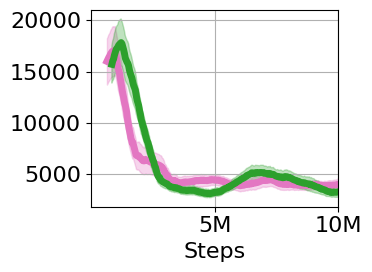

In [8]:
folders = ['logdir/atari_atlantis/Xiper/', 'logdir/atari_atlantis/Viper/']
labels = ['XIPER', 'VIPER', 'Oracle-viper']

color_list = ['tab:pink', 'tab:green', 'tab:grey']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

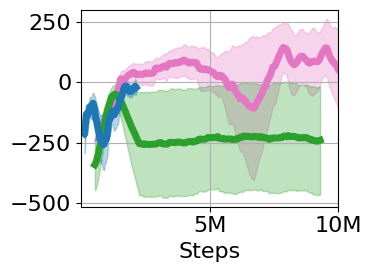

In [22]:
folders = ['logdir/atari_boxing/Xiper/', 'logdir/atari_boxing/Viper/', 'logdir/atari_boxing/XAIL/']
labels = ['XIPER', 'VIPER', 'Oracle-viper']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list, human_normalize=True)

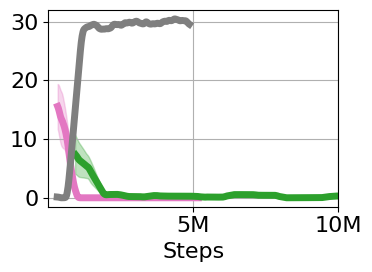

In [10]:
folders = ['logdir/atari_freeway/Xiper/', 'logdir/atari_freeway/Viper/', 'logdir/atari_freeway/Oracle_viper_skip0_selftrained_460/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:grey']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

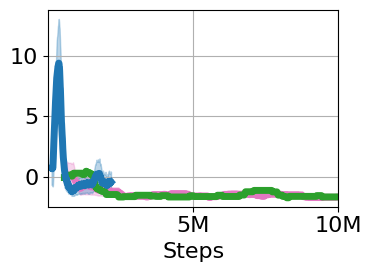

In [21]:
folders = ['logdir/atari_kangaroo/Xiper/', 'logdir/atari_kangaroo/Viper/', 'logdir/atari_kangaroo/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list, human_normalize=True)

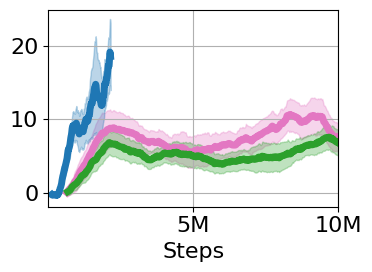

In [20]:
folders = ['logdir/atari_pong/Xiper/', 'logdir/atari_pong/Viper/', 'logdir/atari_pong/XAIL/']
labels = ['XIPER', 'VIPER', 'XAIL']

color_list = ['tab:pink', 'tab:green', 'tab:blue']

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list, human_normalize=True)

### more data on Atari

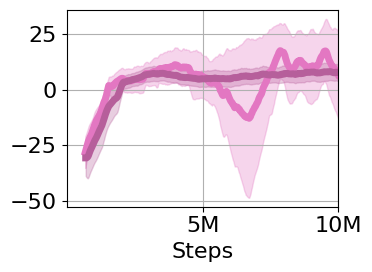

In [8]:
folders = ['logdir/atari_boxing/Xiper/', 'logdir/atari_boxing/Xiper_500/']
labels = ['XIPER-50', 'XIPER-500']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

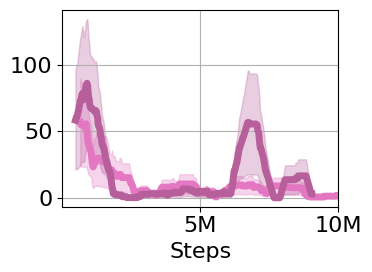

In [9]:
folders = ['logdir/atari_kangaroo/Xiper/', 'logdir/atari_kangaroo/Xiper_500/']
labels = ['XIPER-50', 'XIPER-500']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

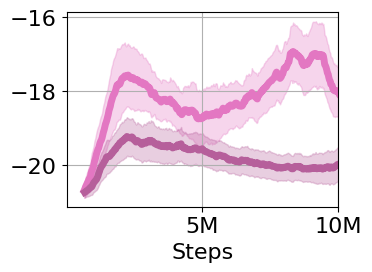

In [10]:
folders = ['logdir/atari_pong/Xiper/', 'logdir/atari_pong/Xiper_500/']
labels = ['XIPER-50', 'XIPER-500']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

### Aggregate all tasks

In [11]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Load and Smooth ----------
def load_scores(file_path):
    steps, scores = [], []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'step' in data and 'episode/score' in data:
                        steps.append(data['step'])
                        scores.append(data['episode/score'])
                except json.JSONDecodeError as e:
                    print(f"[Warning] JSON decode error in {file_path}: {e}")
    except Exception as e:
        print(f"[Warning] Failed to open {file_path}: {e}")
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size) / window_size, mode='valid')

# ---------- Folder Utilities ----------
def find_jsonl_files_recursively(folder_path):
    jsonl_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file == 'scores.jsonl':
                jsonl_files.append(os.path.join(root, file))
    return jsonl_files

# ---------- Core Aggregation: Per Task, Per Run ----------
def aggregate_across_tasks(agent_task_folders, window_size=50, use_ste=True):
    """
    agent_task_folders: list of folder paths (each for a task)
    Returns: steps, averaged mean curve, averaged STE curve
    """
    task_means = []
    task_errors = []
    valid_steps = None

    for folder in agent_task_folders:
        run_files = find_jsonl_files_recursively(folder)
        task_runs = []

        for path in run_files:
            steps, scores = load_scores(path)
            if len(steps) == 0 or len(scores) == 0:
                continue
            sorted_idx = np.argsort(steps)
            steps, scores = steps[sorted_idx], scores[sorted_idx]
            task_runs.append((steps, scores))

        if len(task_runs) == 0:
            print(f"[Warning] No valid runs for {folder}")
            continue

        # Normalize scores within this task
        all_scores_flat = np.concatenate([y for _, y in task_runs])
        #task_min, task_max = np.min(all_scores_flat), np.max(all_scores_flat)
        task_min = 0
        task_max = 1000
        if task_max - task_min > 0:
            task_runs = [(s, (y - task_min) / (task_max - task_min)) for s, y in task_runs]
        else:
            print(f"[Warning] Constant scores in {folder}, skipping normalization.")

        # Shared interpolation range for this task
        min_end = min(s[-1] for s, _ in task_runs)
        max_start = max(s[0] for s, _ in task_runs)
        if min_end <= max_start:
            print(f"[Warning] Overlap issue in {folder}")
            continue

        common_steps = np.linspace(max_start, min_end, 500)
        interpolated = [np.interp(common_steps, s, y) for s, y in task_runs]
        interpolated = np.array(interpolated)

        mean = np.mean(interpolated, axis=0)
        ste = np.std(interpolated, axis=0) / np.sqrt(len(interpolated)) if use_ste else np.std(interpolated, axis=0)

        smoothed_mean = smooth(mean, window_size)
        smoothed_ste = smooth(ste, window_size)
        smoothed_steps = smooth(common_steps, window_size)

        if valid_steps is None:
            valid_steps = smoothed_steps

        task_means.append(smoothed_mean)
        task_errors.append(smoothed_ste)

    if len(task_means) == 0:
        raise ValueError("No valid task data for agent.")

    task_means = np.array(task_means) * task_max
    task_errors = np.array(task_errors) * task_max

    # Average across tasks (mean of means, and RMS of STEs)
    avg_mean = np.mean(task_means, axis=0)
    combined_ste = np.sqrt(np.sum(task_errors ** 2, axis=0)) / len(task_errors)

    return valid_steps, avg_mean, combined_ste

# ---------- Plotting ----------
def plot_agents_across_tasks(agent_task_folders, labels=None, window_size=50, use_ste=True, color_list=['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:purple'], figsize=(3,4)):
    plt.figure(figsize=figsize)

    for i, folders in enumerate(agent_task_folders):
        try:
            steps, mean, err = aggregate_across_tasks(folders, window_size, use_ste)
        except ValueError as e:
            print(f"[Warning] Skipping agent due to: {e}")
            continue

        label = labels[i] if labels else f"Agent {i+1}"
        color = color_list[i % len(color_list)]
        steps_mil = steps / 1e6
        plt.plot(steps_mil, mean, label=label, color=color, linewidth=7)
        plt.fill_between(steps_mil, mean - err, mean + err, color=color, alpha=0.3)

    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}M' if x != 0 else '0'))
    plt.xticks([5, 10], ['5M', '10M'])
    plt.xlabel("Steps")
    #plt.ylabel("Normalized Score")
    #plt.legend(bbox_to_anchor=(0.5, -0.3), loc='upper center')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.xlim(0, 10)
    plt.show()


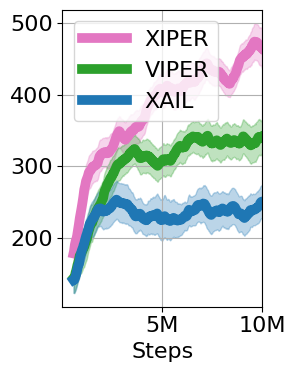

In [42]:
agent_task_folders = [
    ['logdir/DMC_results_xiper_viper/dmc_cheetah_run/Xiper_ot_R/', 
     'logdir/DMC_results_xiper_viper/dmc_cartpole_balance/Xiper_ot_R/', 
     'logdir/DMC_results_xiper_viper/dmc_cartpole_swingup/Xiper_ot_R/',
     'logdir/DMC_results_xiper_viper/dmc_quadruped_walk/Xiper_ot_R/',
     'logdir/DMC_results_xiper_viper/dmc_pointmass_easy/Xiper_ot_R/',
     'logdir/DMC_results_xiper_viper/dmc_cup_catch/Xiper_ot_R/',
     'logdir/DMC_results_xiper_viper/dmc_pendulum_swingup/Xiper_ot_R/',
     'logdir/DMC_results_xiper_viper/dmc_quadruped_run/Xiper_ot_R/'
    ],
    
    ['logdir/DMC_results_xiper_viper/dmc_cheetah_run/Viper/', 
     'logdir/DMC_results_xiper_viper/dmc_cartpole_balance/Viper/', 
     'logdir/DMC_results_xiper_viper/dmc_cartpole_swingup/Viper/',
     'logdir/DMC_results_xiper_viper/dmc_quadruped_walk/Viper_3_seeds/',
     'logdir/DMC_results_xiper_viper/dmc_pointmass_easy/Viper/',
     'logdir/DMC_results_xiper_viper/dmc_cup_catch/Viper_3_seeds/',
     'logdir/DMC_results_xiper_viper/dmc_pendulum_swingup/Viper_3_seeds/',
     'logdir/DMC_results_xiper_viper/dmc_quadruped_run/Viper_3_seeds/'
    ],
      ['logdir/dmc_cheetah_run/XAIL/', 
     'logdir/dmc_cartpole_balance/XAIL/', 
     'logdir/dmc_cartpole_swingup/XAIL/',
     'logdir/dmc_quadruped_walk/XAIL/',
     'logdir/dmc_pointmass_easy/XAIL/',
     'logdir/dmc_cup_catch/XAIL/',
     'logdir/dmc_pendulum_swingup/XAIL/',
     'logdir/dmc_quadruped_run/XAIL/'
    ],
]

labels = ['XIPER', 'VIPER', 'XAIL']
color_list = ['tab:pink', 'tab:green', 'tab:blue']
plot_agents_across_tasks(agent_task_folders, labels, window_size=50, color_list=color_list)


### For Atari Human normalized score

In [16]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Atari Normalization Scores ----------
ATARI_NORMALIZATION_SCORES = {
    'pong': {'random': -20.7, 'human': 14.6},
    'kangaroo': {'random': 52.0, 'human': 3035.0},
    'boxing': {'random': 0.05, 'human': 12.1}
}

# ---------- Load and Smooth ----------
def load_scores(file_path):
    steps, scores = [], []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    if 'step' in data and 'episode/score' in data:
                        steps.append(data['step'])
                        scores.append(data['episode/score'])
                except json.JSONDecodeError as e:
                    print(f"[Warning] JSON decode error in {file_path}: {e}")
    except Exception as e:
        print(f"[Warning] Failed to open {file_path}: {e}")
    return np.array(steps), np.array(scores)

def smooth(y, window_size=50):
    if len(y) < window_size:
        return y
    return np.convolve(y, np.ones(window_size) / window_size, mode='valid')

# ---------- Folder Utilities ----------
def find_jsonl_files_recursively(folder_path):
    jsonl_files = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file == 'scores.jsonl':
                jsonl_files.append(os.path.join(root, file))
    return jsonl_files

# ---------- Core Aggregation: Per Task, Per Run ----------
def aggregate_across_tasks(agent_task_folders, window_size=50, use_ste=True):
    task_means = []
    task_errors = []
    valid_steps = None

    for folder in agent_task_folders:
        run_files = find_jsonl_files_recursively(folder)
        task_runs = []

        for path in run_files:
            steps, scores = load_scores(path)
            if len(steps) == 0 or len(scores) == 0:
                continue
            sorted_idx = np.argsort(steps)
            steps, scores = steps[sorted_idx], scores[sorted_idx]
            task_runs.append((steps, scores))

        if len(task_runs) == 0:
            print(f"[Warning] No valid runs for {folder}")
            continue

        # ---------- Corrected Game Name Extraction ----------
        game_folder = os.path.basename(os.path.dirname(os.path.dirname(folder)))  # e.g., 'atari_pong'
        if 'atari_' in game_folder:
            game_name = game_folder.replace('atari_', '').lower()
        else:
            game_name = game_folder.lower()

        print(f"[Debug] Extracted game name: '{game_name}' from folder: '{folder}'")

        # ---------- Normalize using Atari benchmark ----------
        if game_name in ATARI_NORMALIZATION_SCORES:
            rand = ATARI_NORMALIZATION_SCORES[game_name]['random']
            human = ATARI_NORMALIZATION_SCORES[game_name]['human']
            denom = human - rand
            if denom > 0:
                task_runs = [(s, 100 * (y - rand) / denom) for s, y in task_runs]
            else:
                print(f"[Warning] Invalid normalization range for {game_name}")
                continue
        else:
            print(f"[Warning] No normalization scores for '{game_name}', skipping.")
            continue

        # Shared interpolation range
        min_end = min(s[-1] for s, _ in task_runs)
        max_start = max(s[0] for s, _ in task_runs)
        if min_end <= max_start:
            print(f"[Warning] Overlap issue in {folder}")
            continue

        common_steps = np.linspace(max_start, min_end, 500)
        interpolated = [np.interp(common_steps, s, y) for s, y in task_runs]
        interpolated = np.array(interpolated)

        mean = np.mean(interpolated, axis=0)
        ste = np.std(interpolated, axis=0) / np.sqrt(len(interpolated)) if use_ste else np.std(interpolated, axis=0)

        smoothed_mean = smooth(mean, window_size)
        smoothed_ste = smooth(ste, window_size)
        smoothed_steps = smooth(common_steps, window_size)

        if valid_steps is None:
            valid_steps = smoothed_steps

        task_means.append(smoothed_mean)
        task_errors.append(smoothed_ste)

    if len(task_means) == 0:
        raise ValueError("No valid task data for agent.")

    task_means = np.array(task_means)
    task_errors = np.array(task_errors)

    avg_mean = np.mean(task_means, axis=0)
    combined_ste = np.sqrt(np.sum(task_errors ** 2, axis=0)) / len(task_errors)

    return valid_steps, avg_mean, combined_ste

# ---------- Plotting ----------
def plot_agents_across_tasks(agent_task_folders, labels=None, window_size=50, use_ste=True, color_list=['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:purple'], figsize=(3,4)):
    plt.figure(figsize=figsize)

    for i, folders in enumerate(agent_task_folders):
        try:
            steps, mean, err = aggregate_across_tasks(folders, window_size, use_ste)
        except ValueError as e:
            print(f"[Warning] Skipping agent due to: {e}")
            continue

        label = labels[i] if labels else f"Agent {i+1}"
        color = color_list[i % len(color_list)]
        steps_mil = steps / 1e6
        plt.plot(steps_mil, mean, label=label, color=color, linewidth=7)
        plt.fill_between(steps_mil, mean - err, mean + err, color=color, alpha=0.3)

    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}M' if x != 0 else '0'))
    plt.xticks([5, 10], ['5M', '10M'])
    plt.xlabel("Steps")
    #plt.ylabel("Human Normalized Score (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.xlim(0, 10)
    plt.show()


[Debug] Extracted game name: 'boxing' from folder: 'logdir/atari_boxing/Xiper/'
[Debug] Extracted game name: 'kangaroo' from folder: 'logdir/atari_kangaroo/Xiper/'
[Debug] Extracted game name: 'pong' from folder: 'logdir/atari_pong/Xiper/'
[Debug] Extracted game name: 'boxing' from folder: 'logdir/atari_boxing/Viper/'
[Debug] Extracted game name: 'kangaroo' from folder: 'logdir/atari_kangaroo/Viper/'
[Debug] Extracted game name: 'pong' from folder: 'logdir/atari_pong/Viper/'
[Debug] Extracted game name: 'boxing' from folder: 'logdir/atari_boxing/XAIL/'
[Debug] Extracted game name: 'kangaroo' from folder: 'logdir/atari_kangaroo/XAIL/'
[Debug] Extracted game name: 'pong' from folder: 'logdir/atari_pong/XAIL/'


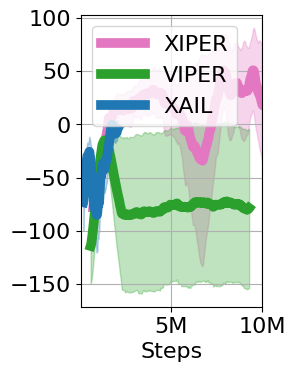

In [18]:
agent_task_folders = [ 
    [
     'logdir/atari_boxing/Xiper/', 
     'logdir/atari_kangaroo/Xiper/',
     'logdir/atari_pong/Xiper/'
    ],
    [
     'logdir/atari_boxing/Viper/', 
     'logdir/atari_kangaroo/Viper/',
     'logdir/atari_pong/Viper/'
    ],
    [
     'logdir/atari_boxing/XAIL/', 
     'logdir/atari_kangaroo/XAIL/',
     'logdir/atari_pong/XAIL/'
    ],
]

labels = ['XIPER', 'VIPER', 'XAIL']
color_list = ['tab:pink', 'tab:green', 'tab:blue']
plot_agents_across_tasks(agent_task_folders, labels, window_size=50, color_list=color_list)

[Debug] Extracted game name: 'boxing' from folder: 'logdir/atari_boxing/Xiper/'
[Debug] Extracted game name: 'kangaroo' from folder: 'logdir/atari_kangaroo/Xiper/'
[Debug] Extracted game name: 'pong' from folder: 'logdir/atari_pong/Xiper/'
[Debug] Extracted game name: 'boxing' from folder: 'logdir/atari_boxing/Xiper_500/'
[Debug] Extracted game name: 'kangaroo' from folder: 'logdir/atari_kangaroo/Xiper_500/'
[Debug] Extracted game name: 'pong' from folder: 'logdir/atari_pong/Xiper_500/'


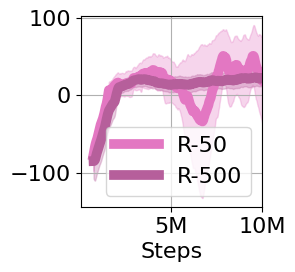

In [15]:
agent_task_folders = [ 
    [
     'logdir/atari_boxing/Xiper/', 
     'logdir/atari_kangaroo/Xiper/',
     'logdir/atari_pong/Xiper/'
    ],
    [
     'logdir/atari_boxing/Xiper_500/', 
     'logdir/atari_kangaroo/Xiper_500/',
     'logdir/atari_pong/Xiper_500/'
    ],
]

labels = ['R-50', 'R-500']
base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]
#color_list = ['tab:pink', 'tab:green', 'tab:blue']
plot_agents_across_tasks(agent_task_folders, labels, window_size=50, color_list=color_list, figsize=(3,3))

### VideoGPT reward visualization

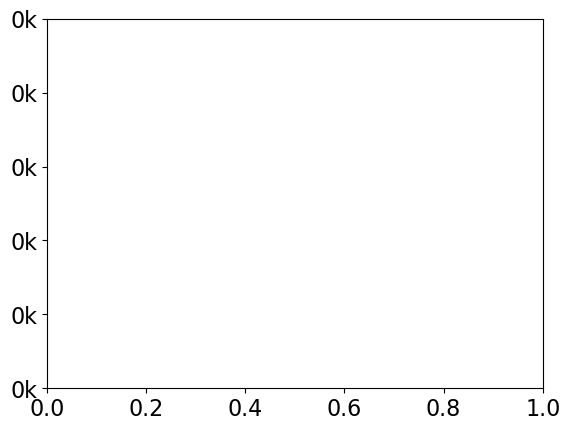

In [20]:
import matplotlib.ticker as mticker

# Format y-axis to show 'k' (e.g., -4k instead of -4000)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# === Load all reward data ===
rewards_xiper_expert = np.load('./good_bad_videos/dmc_cheetah_run/xiper_good.npy', allow_pickle=True)
rewards_xiper_random = np.load('./good_bad_videos/dmc_cheetah_run/xiper_bad.npy', allow_pickle=True)
rewards_viper_expert = np.load('./good_bad_videos/dmc_cheetah_run/viper_good.npy', allow_pickle=True)
rewards_viper_random = np.load('./good_bad_videos/dmc_cheetah_run/viper_bad.npy', allow_pickle=True)

# === Find the minimum sequence length across all datasets ===
min_len = min(
    min(len(r) for r in rewards_xiper_expert),
    min(len(r) for r in rewards_xiper_random),
    min(len(r) for r in rewards_viper_expert),
    min(len(r) for r in rewards_viper_random),
)

# === Trim sequences to same length ===
def trim_rewards(rewards, length):
    return np.array([r[:length] for r in rewards])

rewards_xiper_expert = trim_rewards(rewards_xiper_expert, min_len)
rewards_xiper_random = trim_rewards(rewards_xiper_random, min_len)
rewards_viper_expert = trim_rewards(rewards_viper_expert, min_len)
rewards_viper_random = trim_rewards(rewards_viper_random, min_len)

# === Compute mean and standard error ===
def compute_mean_ste(rewards):
    mean = np.mean(rewards, axis=0)
    ste = np.std(rewards, axis=0) / np.sqrt(len(rewards))
    return mean, ste

mean_xiper_expert, ste_xiper_expert = compute_mean_ste(rewards_xiper_expert)
mean_xiper_random, ste_xiper_random = compute_mean_ste(rewards_xiper_random)
mean_viper_expert, ste_viper_expert = compute_mean_ste(rewards_viper_expert)
mean_viper_random, ste_viper_random = compute_mean_ste(rewards_viper_random)

# === Plot all curves ===
plt.figure(figsize=(3, 3))

# XIPER-expert
plt.plot(smooth(mean_xiper_expert, 50), label='XIPER', color='tab:pink', linewidth=7)
plt.fill_between(range(min_len), mean_xiper_expert - ste_xiper_expert, mean_xiper_expert + ste_xiper_expert,
                 color='tab:pink', alpha=0.3)

# XIPER-random
plt.plot(smooth(mean_xiper_random, 50), color='tab:pink', linewidth=7, linestyle='dotted')
plt.fill_between(range(min_len), mean_xiper_random - ste_xiper_random, mean_xiper_random + ste_xiper_random,
                 color='tab:pink', alpha=0.3)

# VIPER-expert
plt.plot(smooth(mean_viper_expert, 50), label='VIPER', color='tab:green', linewidth=7)
plt.fill_between(range(min_len), mean_viper_expert - ste_viper_expert, mean_viper_expert + ste_viper_expert,
                 color='tab:green', alpha=0.3)

# VIPER-random
plt.plot(smooth(mean_viper_random, 50), color='tab:green', linewidth=7, linestyle='dotted')
plt.fill_between(range(min_len), mean_viper_random - ste_viper_random, mean_viper_random + ste_viper_random,
                 color='tab:green', alpha=0.3)

# === Legend and labels ===
options = dict(
    fontsize='large', numpoints=1, labelspacing=0, columnspacing=1.2,
    handlelength=1.5, handletextpad=0.5, ncol=2, loc='lower center', frameon=True, fancybox=True
)
#plt.legend(bbox_to_anchor=(0.5, -0.5), **options)
plt.legend(framealpha=0.8)
plt.xlim(0, 500)
plt.ylabel('Reward Model Output')
plt.xlabel('Step')
plt.grid(True)

# === Format y-axis ticks ===
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './good_bad_videos/dmc_cheetah_run/xiper_good.npy'

### Different FID

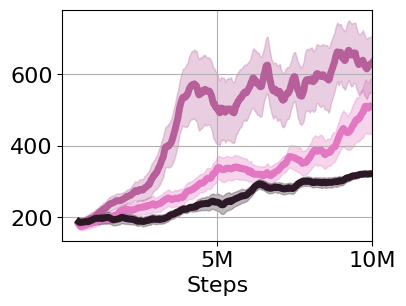

In [28]:
folders = ['logdir/dmc_cartpole_balance/Xiper_ot_R/', 'logdir/dmc_cartpole_balance/Xiper_ot_R_fid_Mid/', 'logdir/dmc_cartpole_balance/Xiper_ot_R_fid_High/']
labels = ['FID10', 'FID18', 'FID33']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

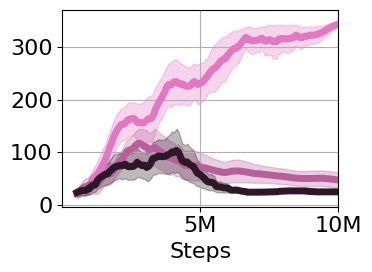

In [25]:
folders = ['logdir/dmc_cheetah_run/Xiper_ot_R/', 'logdir/dmc_cheetah_run/Xiper_ot_R_fid_Mid/', 'logdir/dmc_cheetah_run/Xiper_ot_R_fid_High/']
labels = ['FID2', 'FID6', 'FID13']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

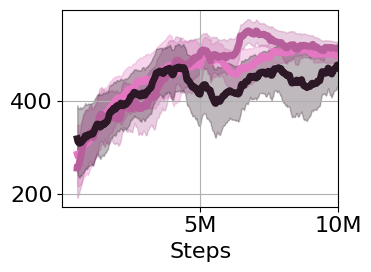

In [26]:
folders = ['logdir/dmc_quadruped_walk/Xiper_ot_R/', 'logdir/dmc_quadruped_walk/Xiper_ot_R_fid_Mid/', 'logdir/dmc_quadruped_walk/Xiper_ot_R_fid_High/']
labels = ['FID20', 'FID33', 'FID53']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 1), adjust_shade(base_rgb, 0.8), adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.2)]

plot_agent_folders(folders, labels, window_size=50, use_ste=True, color_list=color_list)

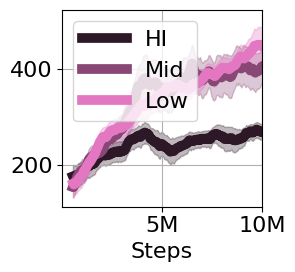

In [30]:
agent_task_folders = [
    ['logdir/dmc_cheetah_run/Xiper_ot_R_fid_High/', 
     'logdir/dmc_cartpole_balance/Xiper_ot_R_fid_High/', 
     'logdir/dmc_quadruped_walk/Xiper_ot_R_fid_High/'
    ],
    
    ['logdir/dmc_cheetah_run/Xiper_ot_R_fid_Mid/', 
     'logdir/dmc_cartpole_balance/Xiper_ot_R_fid_Mid/', 
     'logdir/dmc_quadruped_walk/Xiper_ot_R_fid_Mid/'
    ],
    
    ['logdir/dmc_cheetah_run/Xiper_ot_R/', 
     'logdir/dmc_cartpole_balance/Xiper_ot_R/', 
     'logdir/dmc_quadruped_walk/Xiper_ot_R/'
    ]
]

labels = ['HI', 'Mid', 'Low']

base_rgb = to_rgb('tab:pink')
color_list=[adjust_shade(base_rgb, 0.2), adjust_shade(base_rgb, 0.6), adjust_shade(base_rgb, 1)]

plot_agents_across_tasks(agent_task_folders, labels, window_size=50, color_list=color_list, figsize=(3,3))
